In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

np.random.seed(42)

# 7 days of data at 1 minute intervals for one station
timestamps = pd.date_range(start="2024-01-15 00:00", periods=7*24*60, freq="min")
n = len(timestamps)

print(f"Total data points: {n}")
print(f"Start: {timestamps[0]}")
print(f"End: {timestamps[-1]}")

Total data points: 10080
Start: 2024-01-15 00:00:00
End: 2024-01-21 23:59:00


In [2]:
# Start with a realistic baseline pressure signal
# Normal operating pressure around 250 bar with small natural variation
pressure = np.random.normal(250, 3, n)

# 1 - DRIFT: sensor slowly drifting from day 4 onward
# Simulates hydrogen membrane contamination
drift_start = 4 * 24 * 60  # minute 5760 = day 4
drift = np.zeros(n)
drift[drift_start:] = np.linspace(0, 25, n - drift_start)
pressure = pressure + drift

# 2 - SPIKE: sudden single point outliers (false alarms)
# 5 random spikes scattered through the week
spike_indices = np.random.choice(n, 5)
pressure[spike_indices] = pressure[spike_indices] + np.random.uniform(40, 80, 5)

# 3 - CLIPPING: PLC range error - values stuck at 280 bar
# affects a 2 hour window on day 2
clip_start = 2 * 24 * 60
clip_end = clip_start + 120
pressure[clip_start:clip_end] = 280

# 4 - MISSING VALUES: exception reporting / comms dropout
# Random gaps simulating deadband reporting and dropouts
missing_indices = np.random.choice(n, 500, replace=False)
pressure[missing_indices] = np.nan

# Build the DataFrame
ts_df = pd.DataFrame({
    "timestamp": timestamps,
    "pressure": pressure
})

print(ts_df.shape)
print(f"Missing values: {ts_df['pressure'].isna().sum()}")
print(ts_df.head(10))

(10080, 2)
Missing values: 500
            timestamp    pressure
0 2024-01-15 00:00:00  251.490142
1 2024-01-15 00:01:00  249.585207
2 2024-01-15 00:02:00         NaN
3 2024-01-15 00:03:00  254.569090
4 2024-01-15 00:04:00  249.297540
5 2024-01-15 00:05:00  249.297589
6 2024-01-15 00:06:00         NaN
7 2024-01-15 00:07:00  252.302304
8 2024-01-15 00:08:00  248.591577
9 2024-01-15 00:09:00  251.627680


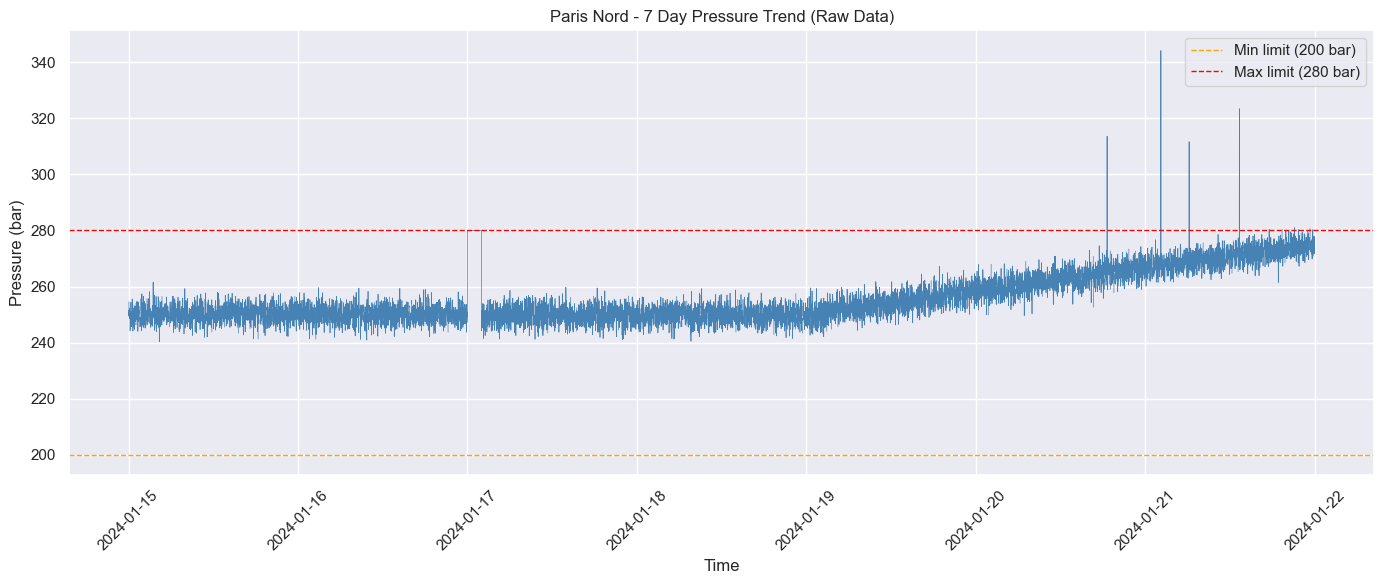

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ts_df["timestamp"], ts_df["pressure"], 
        linewidth=0.5, color="steelblue")

ax.axhline(y=200, color="orange", linestyle="--", linewidth=1, label="Min limit (200 bar)")
ax.axhline(y=280, color="red", linestyle="--", linewidth=1, label="Max limit (280 bar)")

ax.set_title("Paris Nord - 7 Day Pressure Trend (Raw Data)")
ax.set_xlabel("Time")
ax.set_ylabel("Pressure (bar)")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# DATA QUALITY DETECTION

# 1 - MISSING VALUES
missing_count = ts_df["pressure"].isna().sum()
missing_pct = (missing_count / n) * 100

# 2 - SPIKES: readings more than 3 standard deviations from the rolling mean
rolling_mean = ts_df["pressure"].rolling(window=60, min_periods=1).mean()
rolling_std = ts_df["pressure"].rolling(window=60, min_periods=1).std()
spikes = ts_df[np.abs(ts_df["pressure"] - rolling_mean) > (3 * rolling_std)]

# 3 - CLIPPING: values stuck at exactly the same value for more than 10 consecutive readings
clipping = ts_df["pressure"].diff() == 0
clipping_runs = clipping.rolling(window=10).sum()
clipped = ts_df[clipping_runs >= 10]

# 4 - DRIFT: rolling mean deviating more than 15 bar from overall mean
overall_mean = ts_df["pressure"].mean()
drift_detected = ts_df[np.abs(rolling_mean - overall_mean) > 15]

print(f"Missing values: {missing_count} ({missing_pct:.1f}%)")
print(f"Spikes detected: {len(spikes)}")
print(f"Clipped readings: {len(clipped)}")
print(f"Drift readings: {len(drift_detected)}")

Missing values: 500 (5.0%)
Spikes detected: 30
Clipped readings: 38
Drift readings: 830


In [5]:
# IMPROVED DETECTORS

# 1 - SPIKES: use a larger window and only flag the peak point
rolling_mean = ts_df["pressure"].rolling(window=60, min_periods=1).mean()
rolling_std = ts_df["pressure"].rolling(window=60, min_periods=1).std()

deviation = np.abs(ts_df["pressure"] - rolling_mean)
# Only flag if this point is higher than its neighbours (local peak)
spikes = ts_df[
    (deviation > 3 * rolling_std) & 
    (deviation > deviation.shift(1)) & 
    (deviation > deviation.shift(-1))
]

# 2 - DRIFT: lower threshold and use a longer window to smooth noise
long_rolling_mean = ts_df["pressure"].rolling(window=240, min_periods=1).mean()
drift_detected = ts_df[np.abs(long_rolling_mean - overall_mean) > 8]

print(f"Spikes detected: {len(spikes)}")
print(f"Drift readings: {len(drift_detected)}")

Spikes detected: 22
Drift readings: 1941


In [6]:
# ROBUST SPIKE DETECTION using median instead of mean
rolling_median = ts_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (ts_df["pressure"] - rolling_median).abs().rolling(window=60, min_periods=1).median()

# Flag points that deviate more than 6x the median absolute deviation
spikes = ts_df[
    (np.abs(ts_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (ts_df["pressure"].notna())
]

print(f"Spikes detected: {len(spikes)}")

Spikes detected: 64


In [7]:
# SEQUENTIAL CLEANING PIPELINE

# Work on a copy - never modify the original raw data
clean_df = ts_df.copy()

# STEP 1 - FLAG CLIPPING: mark clipped values as NaN
# (they are unusable - PLC configuration error)
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df.loc[clipping_runs >= 10, "pressure"] = np.nan

# STEP 2 - FLAG DRIFT: add a column marking drifting periods
long_rolling_mean = clean_df["pressure"].rolling(window=240, min_periods=1).mean()
overall_mean = clean_df["pressure"].mean()
clean_df["drift_flag"] = np.abs(long_rolling_mean - overall_mean) > 8

# STEP 3 - HANDLE MISSING VALUES: forward fill then backward fill
# Forward fill = carry last known value forward
# Backward fill = for any remaining gaps at the start, fill backwards
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()

# STEP 4 - DETECT SPIKES on the cleaned signal
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)

print(f"Clipped values removed: {clean_df['pressure'].isna().sum()}")
print(f"Drift periods flagged: {clean_df['drift_flag'].sum()}")
print(f"Spikes flagged: {clean_df['spike_flag'].sum()}")

Clipped values removed: 0
Drift periods flagged: 1818
Spikes flagged: 70


In [8]:
# IMPROVED SEQUENTIAL CLEANING PIPELINE

# Work on a clean copy
clean_df = ts_df.copy()

# ── STEP 1: FLAG CLIPPING ──────────────────────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10

clipping_count = clean_df["clipping_flag"].sum()
print(f"Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT AND CORRECT DRIFT ──────────────────
# Calculate rolling mean of rate of change over 2 hour window
rate_of_change = clean_df["pressure"].diff()
rolling_roc = rate_of_change.rolling(window=120, min_periods=1).mean()

# Find drift start - first point where rolling ROC consistently exceeds threshold
drift_threshold = 0.05  # bar per minute
drift_mask = np.abs(rolling_roc) > drift_threshold

# Find the first timestamp where drift begins
drift_start_idx = drift_mask.idxmax()  # idxmax returns index of first True value
print(f"Drift detected starting at: {clean_df.loc[drift_start_idx, 'timestamp']}")

# Calculate correction vector from drift start
# Estimate drift rate as the mean ROC from drift start onward
drift_rate = rolling_roc[drift_start_idx:].mean()
print(f"Estimated drift rate: {drift_rate:.4f} bar/minute")

# Build correction vector - 0 before drift start, growing linearly after
correction = np.zeros(n)
drift_length = n - drift_start_idx
correction[drift_start_idx:] = np.arange(drift_length) * drift_rate

# Apply correction
clean_df["pressure_corrected"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = drift_mask

drift_count = clean_df["drift_flag"].sum()
print(f"Drift periods flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure_corrected"].isna().sum()
clean_df["pressure_corrected"] = clean_df["pressure_corrected"].ffill().bfill()
print(f"Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure_corrected"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure_corrected"] - rolling_median).abs().rolling(window=60, min_periods=1).median()

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure_corrected"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure_corrected"].notna())
)

spike_count = clean_df["spike_flag"].sum()
print(f"Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──")
print(f"Total readings:        {n}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")

Clipped readings flagged: 38
Drift detected starting at: 2024-01-15 00:01:00
Estimated drift rate: -0.0138 bar/minute
Drift periods flagged: 6312
Missing values filled: 500
Spikes flagged: 66

── Data Quality Summary ──
Total readings:        10080
Clipped readings:      38 (0.4%)
Drift periods:         6312 (62.6%)
Missing values filled: 500 (5.0%)
Spikes flagged:        66 (0.7%)


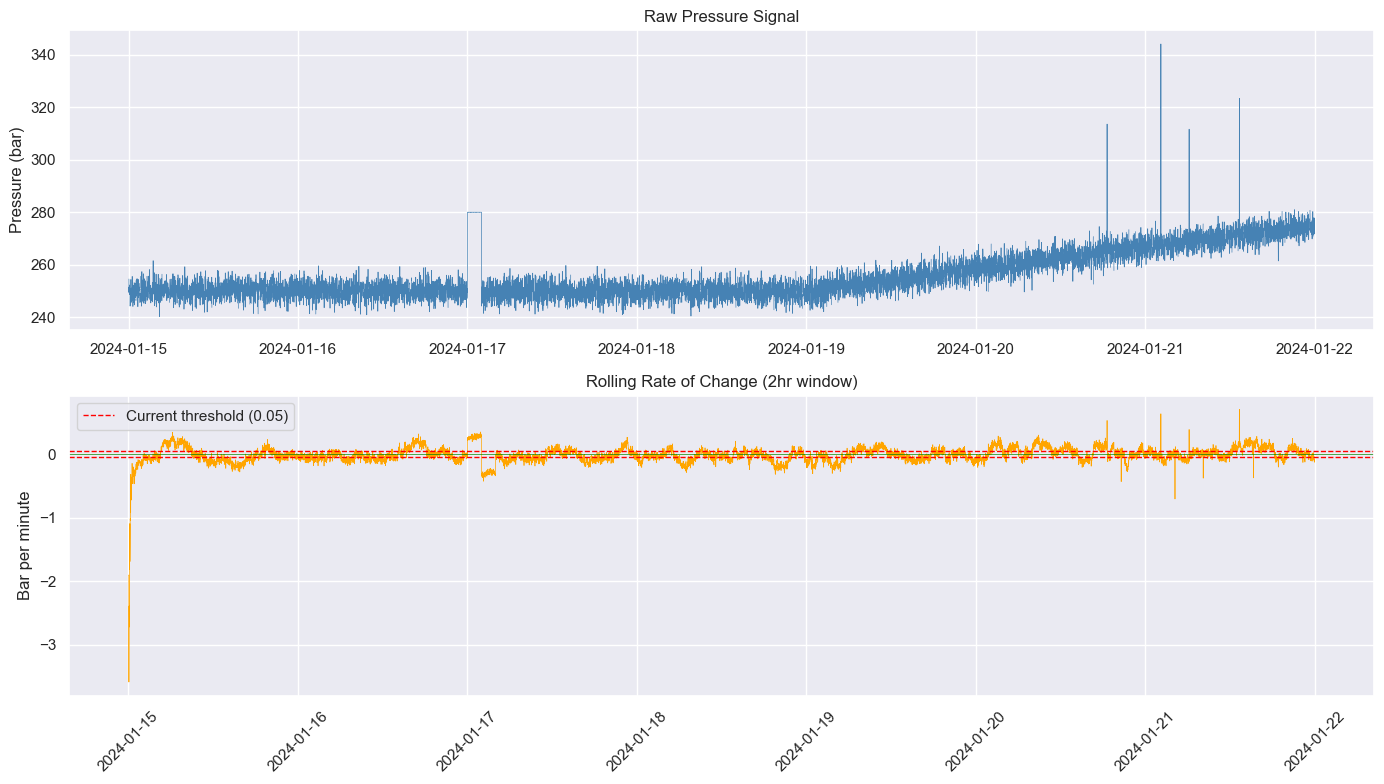

In [9]:
# Examine the rate of change signal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Top chart - raw pressure
ax1.plot(ts_df["timestamp"], ts_df["pressure"], linewidth=0.5, color="steelblue")
ax1.set_title("Raw Pressure Signal")
ax1.set_ylabel("Pressure (bar)")

# Bottom chart - rolling rate of change
ax2.plot(clean_df["timestamp"], rolling_roc, linewidth=0.5, color="orange")
ax2.axhline(y=0.05, color="red", linestyle="--", linewidth=1, label="Current threshold (0.05)")
ax2.axhline(y=-0.05, color="red", linestyle="--", linewidth=1)
ax2.axhline(y=0, color="green", linestyle="-", linewidth=0.5)
ax2.set_title("Rolling Rate of Change (2hr window)")
ax2.set_ylabel("Bar per minute")
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Baseline mean: 250.85 bar
Baseline std: 4.98 bar
Drift detection threshold: 260.81 bar


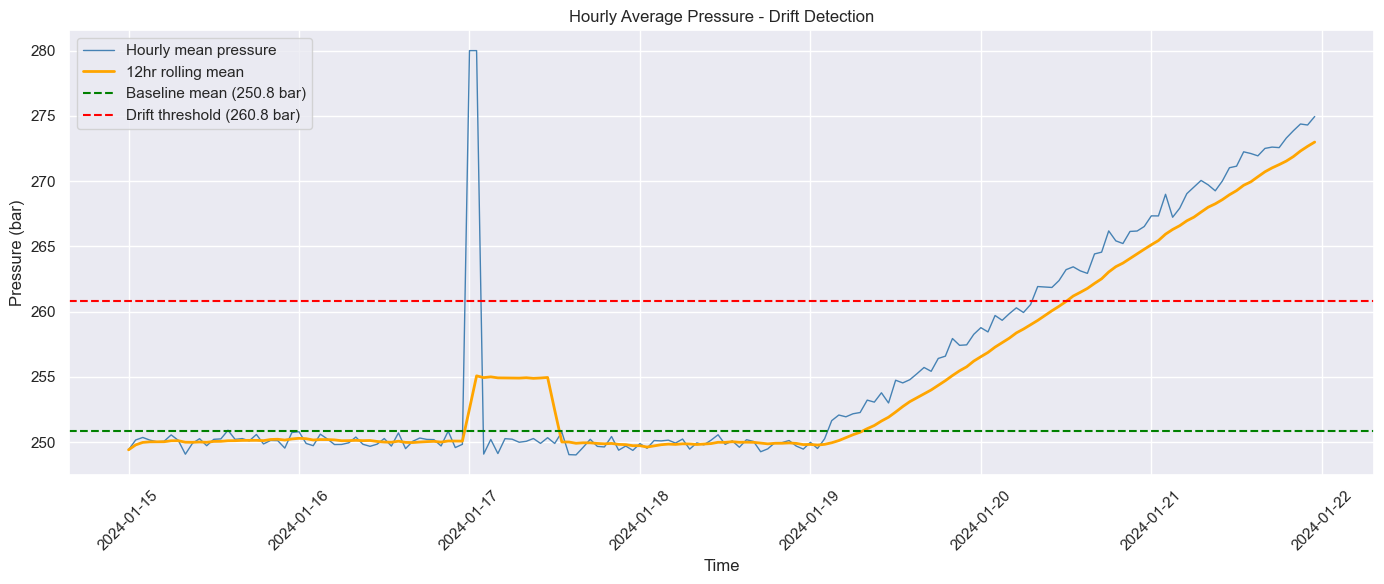

In [10]:
# SLOW DRIFT DETECTION using hourly averages
# Resample to hourly means - noise averages out
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate rolling mean over 12 hour window on hourly data
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Overall baseline - use first 3 days only (before drift starts)
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

print(f"Baseline mean: {baseline_mean:.2f} bar")
print(f"Baseline std: {baseline_std:.2f} bar")
print(f"Drift detection threshold: {baseline_mean + 2*baseline_std:.2f} bar")

# Plot hourly averages
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hourly_df["timestamp"], hourly_df["pressure"], 
        linewidth=1, color="steelblue", label="Hourly mean pressure")
ax.plot(hourly_df["timestamp"], hourly_df["rolling_mean"], 
        linewidth=2, color="orange", label="12hr rolling mean")
ax.axhline(y=baseline_mean, color="green", linestyle="--", label=f"Baseline mean ({baseline_mean:.1f} bar)")
ax.axhline(y=baseline_mean + 2*baseline_std, color="red", linestyle="--", 
           label=f"Drift threshold ({baseline_mean + 2*baseline_std:.1f} bar)")
ax.set_title("Hourly Average Pressure - Drift Detection")
ax.set_ylabel("Pressure (bar)")
ax.set_xlabel("Time")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# COMPLETE SEQUENTIAL CLEANING PIPELINE v3

# Work on a fresh copy of the raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT DRIFT USING HOURLY RESAMPLING ──────
# Resample to hourly means - smooths out noise
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate baseline from first 3 days - now clean of clipping
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()
drift_threshold = baseline_mean + 2 * baseline_std
print(f"Step 2 - Baseline mean: {baseline_mean:.2f} bar")
print(f"Step 2 - Drift threshold: {drift_threshold:.2f} bar")

# Find drift start - first hour where 12hr rolling mean exceeds threshold
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()
drift_hours = hourly_df[hourly_df["rolling_mean"] > drift_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Step 2 - Drift detected from: {drift_start_timestamp}")

# Map drift start back to minute-level data
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

# Estimate drift rate from hourly data after drift start
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
print(f"Step 2 - Estimated drift rate: {drift_rate:.4f} bar/hour")

# Build and apply correction at minute level
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 2 - Drift readings flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 3 - Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 4 - Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")



Step 1 - Clipped readings flagged: 38
Step 2 - Baseline mean: 250.85 bar
Step 2 - Drift threshold: 260.81 bar
Step 2 - Drift detected from: 2024-01-20 13:00:00
Step 2 - Estimated drift rate: 0.3290 bar/hour
Step 2 - Drift readings flagged: 2100
Step 3 - Missing values filled: 538
Step 4 - Spikes flagged: 70

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Drift periods:         2100 (20.8%)
Missing values filled: 538 (5.3%)
Spikes flagged:        70 (0.7%)


In [12]:
# COMPLETE SEQUENTIAL CLEANING PIPELINE v3

# Work on a fresh copy of the raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT DRIFT USING HOURLY RESAMPLING ──────
# Resample to hourly means - smooths out noise
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate baseline from first 3 days - now clean of clipping
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()
drift_threshold = baseline_mean + 2 * baseline_std
print(f"Step 2 - Baseline mean: {baseline_mean:.2f} bar")
print(f"Step 2 - Drift threshold: {drift_threshold:.2f} bar")

# Find drift start - first hour where 12hr rolling mean exceeds threshold
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()
drift_hours = hourly_df[hourly_df["rolling_mean"] > drift_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Step 2 - Drift detected from: {drift_start_timestamp}")

# Map drift start back to minute-level data
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

# Estimate drift rate from hourly data after drift start
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
print(f"Step 2 - Estimated drift rate: {drift_rate:.4f} bar/hour")

# Build and apply correction at minute level
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 2 - Drift readings flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 3 - Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 4 - Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")

Step 1 - Clipped readings flagged: 38
Step 2 - Baseline mean: 250.85 bar
Step 2 - Drift threshold: 260.81 bar
Step 2 - Drift detected from: 2024-01-20 13:00:00
Step 2 - Estimated drift rate: 0.3290 bar/hour
Step 2 - Drift readings flagged: 2100
Step 3 - Missing values filled: 538
Step 4 - Spikes flagged: 70

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Drift periods:         2100 (20.8%)
Missing values filled: 538 (5.3%)
Spikes flagged:        70 (0.7%)


In [13]:
# COMPLETE SEQUENTIAL CLEANING PIPELINE v3

# Work on a fresh copy of the raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT DRIFT USING HOURLY RESAMPLING ──────
# Resample to hourly means - smooths out noise
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate baseline from first 3 days - now clean of clipping
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()
drift_threshold = baseline_mean + 2 * baseline_std
print(f"Step 2 - Baseline mean: {baseline_mean:.2f} bar")
print(f"Step 2 - Drift threshold: {drift_threshold:.2f} bar")

# Find drift start - first hour where 12hr rolling mean exceeds threshold
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()
drift_hours = hourly_df[hourly_df["rolling_mean"] > drift_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Step 2 - Drift detected from: {drift_start_timestamp}")

# Map drift start back to minute-level data
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

# Estimate drift rate from hourly data after drift start
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
print(f"Step 2 - Estimated drift rate: {drift_rate:.4f} bar/hour")

# Build and apply correction at minute level
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 2 - Drift readings flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 3 - Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 4 - Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")

Step 1 - Clipped readings flagged: 38
Step 2 - Baseline mean: 250.85 bar
Step 2 - Drift threshold: 260.81 bar
Step 2 - Drift detected from: 2024-01-20 13:00:00
Step 2 - Estimated drift rate: 0.3290 bar/hour
Step 2 - Drift readings flagged: 2100
Step 3 - Missing values filled: 538
Step 4 - Spikes flagged: 70

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Drift periods:         2100 (20.8%)
Missing values filled: 538 (5.3%)
Spikes flagged:        70 (0.7%)


In [14]:
# COMPLETE SEQUENTIAL CLEANING PIPELINE v3

# Work on a fresh copy of the raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT DRIFT USING HOURLY RESAMPLING ──────
# Resample to hourly means - smooths out noise
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate baseline from first 3 days - now clean of clipping
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()
drift_threshold = baseline_mean + 2 * baseline_std
print(f"Step 2 - Baseline mean: {baseline_mean:.2f} bar")
print(f"Step 2 - Drift threshold: {drift_threshold:.2f} bar")

# Find drift start - first hour where 12hr rolling mean exceeds threshold
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()
drift_hours = hourly_df[hourly_df["rolling_mean"] > drift_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Step 2 - Drift detected from: {drift_start_timestamp}")

# Map drift start back to minute-level data
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

# Estimate drift rate from hourly data after drift start
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
print(f"Step 2 - Estimated drift rate: {drift_rate:.4f} bar/hour")

# Build and apply correction at minute level
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 2 - Drift readings flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 3 - Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 4 - Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")

Step 1 - Clipped readings flagged: 38
Step 2 - Baseline mean: 250.85 bar
Step 2 - Drift threshold: 260.81 bar
Step 2 - Drift detected from: 2024-01-20 13:00:00
Step 2 - Estimated drift rate: 0.3290 bar/hour
Step 2 - Drift readings flagged: 2100
Step 3 - Missing values filled: 538
Step 4 - Spikes flagged: 70

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Drift periods:         2100 (20.8%)
Missing values filled: 538 (5.3%)
Spikes flagged:        70 (0.7%)


In [15]:
# Debug - check what ts_df looks like before cleaning
print("Raw ts_df:")
print(f"Shape: {ts_df.shape}")
print(f"Missing values: {ts_df['pressure'].isna().sum()}")
print(f"Max pressure: {ts_df['pressure'].max():.1f}")
print(f"Min pressure: {ts_df['pressure'].min():.1f}")
print(f"Values at 280 bar: {(ts_df['pressure'] == 280).sum()}")
print()

# Check clean_df after step 1
print("After Step 1:")
print(f"Clipping flags: {clean_df['clipping_flag'].sum()}")
print(f"NaN values after flagging: {clean_df['pressure'].isna().sum()}")
print(f"Values still at 280: {(clean_df['pressure'] == 280).sum()}")

Raw ts_df:
Shape: (10080, 2)
Missing values: 500
Max pressure: 344.1
Min pressure: 240.3
Values at 280 bar: 112

After Step 1:
Clipping flags: 38
NaN values after flagging: 0
Values still at 280: 120


In [16]:
# Debug Step 1
print(clean_df["clipping_flag"].value_counts())
print()
print(clean_df.loc[clean_df["clipping_flag"] == True, "pressure"].head(10))

clipping_flag
False    10042
True        38
Name: count, dtype: int64

2900    280.0
2901    280.0
2928    280.0
2929    280.0
2930    280.0
2931    280.0
2943    280.0
2944    280.0
2945    280.0
2946    280.0
Name: pressure, dtype: float64


In [17]:
# Test the NaN replacement directly
print(f"Before: {clean_df.loc[clean_df['clipping_flag'] == True, 'pressure'].isna().sum()} NaN values in flagged rows")

clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan

print(f"After: {clean_df.loc[clean_df['clipping_flag'] == True, 'pressure'].isna().sum()} NaN values in flagged rows")
print(f"Total NaN in pressure column: {clean_df['pressure'].isna().sum()}")

Before: 0 NaN values in flagged rows
After: 38 NaN values in flagged rows
Total NaN in pressure column: 38


In [54]:
# COMPLETE SEQUENTIAL CLEANING PIPELINE v3

# Work on a fresh copy of the raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
print(f"DEBUG after NaN replacement: {clean_df['pressure'].isna().sum()} NaN values")
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT DRIFT USING HOURLY RESAMPLING ──────
# Resample to hourly means - smooths out noise
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate baseline from first 3 days - now clean of clipping
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()
drift_threshold = baseline_mean + 2 * baseline_std
print(f"Step 2 - Baseline mean: {baseline_mean:.2f} bar")
print(f"Step 2 - Drift threshold: {drift_threshold:.2f} bar")

# Find drift start - first hour where 12hr rolling mean exceeds threshold
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()
drift_hours = hourly_df[hourly_df["rolling_mean"] > drift_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Step 2 - Drift detected from: {drift_start_timestamp}")

# Map drift start back to minute-level data
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

# Estimate drift rate from hourly data after drift start
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
print(f"Step 2 - Estimated drift rate: {drift_rate:.4f} bar/hour")

# Build and apply correction at minute level
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 2 - Drift readings flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 3 - Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 4 - Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")

DEBUG after NaN replacement: 538 NaN values
Step 1 - Clipped readings flagged: 38
Step 2 - Baseline mean: 250.85 bar
Step 2 - Drift threshold: 260.81 bar
Step 2 - Drift detected from: 2024-01-20 13:00:00
Step 2 - Estimated drift rate: 0.3290 bar/hour
Step 2 - Drift readings flagged: 2100
Step 3 - Missing values filled: 538
Step 4 - Spikes flagged: 70

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Drift periods:         2100 (20.8%)
Missing values filled: 538 (5.3%)
Spikes flagged:        70 (0.7%)


In [55]:
# Where are the spikes being detected?
spike_df = clean_df[clean_df["spike_flag"] == True]
print(f"Total spikes flagged: {len(spike_df)}")
print(f"\nFirst 10 flagged spikes:")
print(spike_df[["timestamp", "pressure"]].head(10))
print(f"\nLast 10 flagged spikes:")
print(spike_df[["timestamp", "pressure"]].tail(10))

Total spikes flagged: 70

First 10 flagged spikes:
               timestamp    pressure
3    2024-01-15 00:03:00  254.569090
7    2024-01-15 00:07:00  252.302304
209  2024-01-15 03:29:00  261.558194
2880 2024-01-17 00:00:00  280.000000
2881 2024-01-17 00:01:00  280.000000
2882 2024-01-17 00:02:00  280.000000
2883 2024-01-17 00:03:00  280.000000
2884 2024-01-17 00:04:00  280.000000
2885 2024-01-17 00:05:00  280.000000
2886 2024-01-17 00:06:00  280.000000

Last 10 flagged spikes:
               timestamp    pressure
4193 2024-01-17 21:53:00  242.720824
4198 2024-01-17 21:58:00  240.977103
5846 2024-01-19 01:26:00  259.279611
6891 2024-01-19 18:51:00  267.133820
8200 2024-01-20 16:40:00  251.407298
8315 2024-01-20 18:35:00  311.723231
8772 2024-01-21 02:12:00  339.715096
9012 2024-01-21 06:12:00  305.952333
9439 2024-01-21 13:19:00  315.354676
9770 2024-01-21 18:50:00  251.628688


In [56]:
# COMPLETE SEQUENTIAL CLEANING PIPELINE v3

# Work on a fresh copy of the raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
print(f"Values still at 280 after NaN replacement: {(clean_df['pressure'] == 280.0).sum()}")
print(f"NaN count after replacement: {clean_df['pressure'].isna().sum()}")
print(f"DEBUG after NaN replacement: {clean_df['pressure'].isna().sum()} NaN values")
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: DETECT DRIFT USING HOURLY RESAMPLING ──────
# Resample to hourly means - smooths out noise
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()

# Calculate baseline from first 3 days - now clean of clipping
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()
drift_threshold = baseline_mean + 2 * baseline_std
print(f"Step 2 - Baseline mean: {baseline_mean:.2f} bar")
print(f"Step 2 - Drift threshold: {drift_threshold:.2f} bar")

# Find drift start - first hour where 12hr rolling mean exceeds threshold
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()
drift_hours = hourly_df[hourly_df["rolling_mean"] > drift_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Step 2 - Drift detected from: {drift_start_timestamp}")

# Map drift start back to minute-level data
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

# Estimate drift rate from hourly data after drift start
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
print(f"Step 2 - Estimated drift rate: {drift_rate:.4f} bar/hour")

# Build and apply correction at minute level
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 2 - Drift readings flagged: {drift_count}")

# ── STEP 3: HANDLE MISSING VALUES ─────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 3 - Missing values filled: {missing_before}")

# ── STEP 4: DETECT SPIKES ON CLEAN SIGNAL ─────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()
clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 6 * rolling_mad) &
    (clean_df["pressure"].notna())
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 4 - Spikes flagged: {spike_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")

Values still at 280 after NaN replacement: 74
NaN count after replacement: 538
DEBUG after NaN replacement: 538 NaN values
Step 1 - Clipped readings flagged: 38
Step 2 - Baseline mean: 250.85 bar
Step 2 - Drift threshold: 260.81 bar
Step 2 - Drift detected from: 2024-01-20 13:00:00
Step 2 - Estimated drift rate: 0.3290 bar/hour
Step 2 - Drift readings flagged: 2100
Step 3 - Missing values filled: 538
Step 4 - Spikes flagged: 70

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Drift periods:         2100 (20.8%)
Missing values filled: 538 (5.3%)
Spikes flagged:        70 (0.7%)


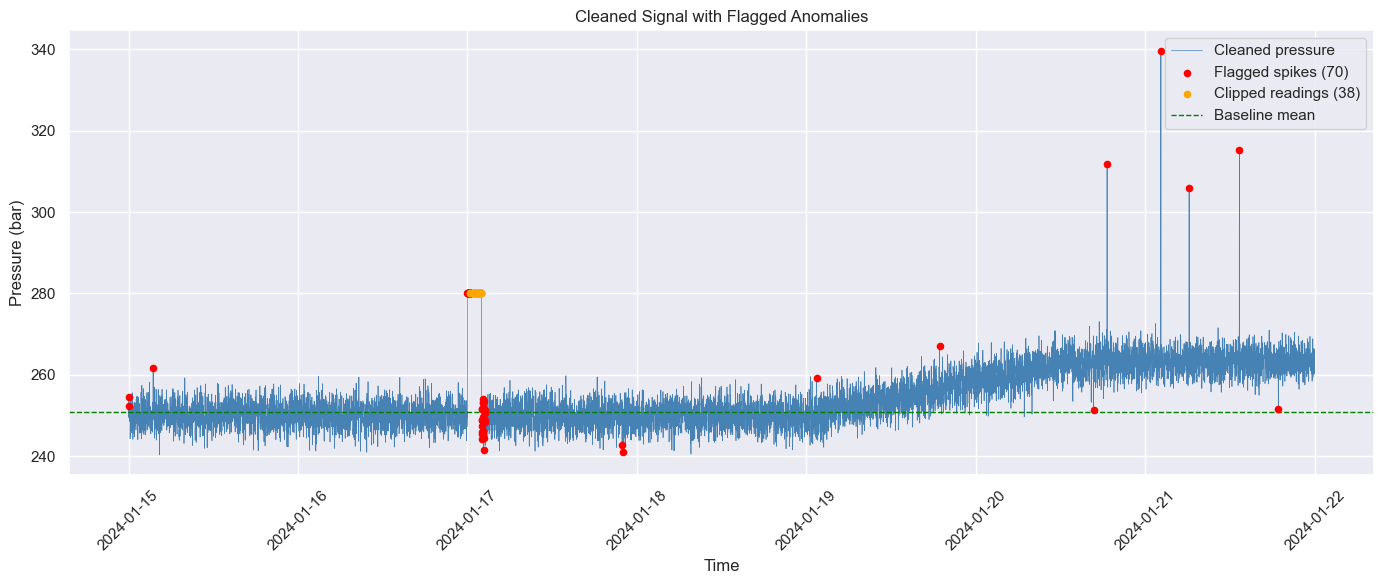

In [57]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot cleaned pressure
ax.plot(clean_df["timestamp"], clean_df["pressure"], 
        linewidth=0.5, color="steelblue", label="Cleaned pressure")

# Highlight flagged spikes in red
spikes_only = clean_df[clean_df["spike_flag"] == True]
ax.scatter(spikes_only["timestamp"], spikes_only["pressure"], 
           color="red", s=20, zorder=5, label=f"Flagged spikes ({len(spikes_only)})")

# Highlight clipped readings in orange
clipped_only = clean_df[clean_df["clipping_flag"] == True]
ax.scatter(clipped_only["timestamp"], clipped_only["pressure"],
           color="orange", s=20, zorder=5, label=f"Clipped readings ({len(clipped_only)})")

ax.axhline(y=baseline_mean, color="green", linestyle="--", linewidth=1, label="Baseline mean")
ax.set_title("Cleaned Signal with Flagged Anomalies")
ax.set_ylabel("Pressure (bar)")
ax.set_xlabel("Time")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
# Fix 1 - exclude warmup period from spike detection (first 60 mins)
# Fix 2 - exclude clipped regions from spike detection
# Fix 3 - increase threshold from 6 to 8 MAD

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clean_df["clipping_flag"] == False) &
    (clean_df.index >= 60)  # skip first 60 minutes warmup
)

spike_count = clean_df["spike_flag"].sum()
print(f"Spikes flagged: {spike_count}")

Spikes flagged: 57


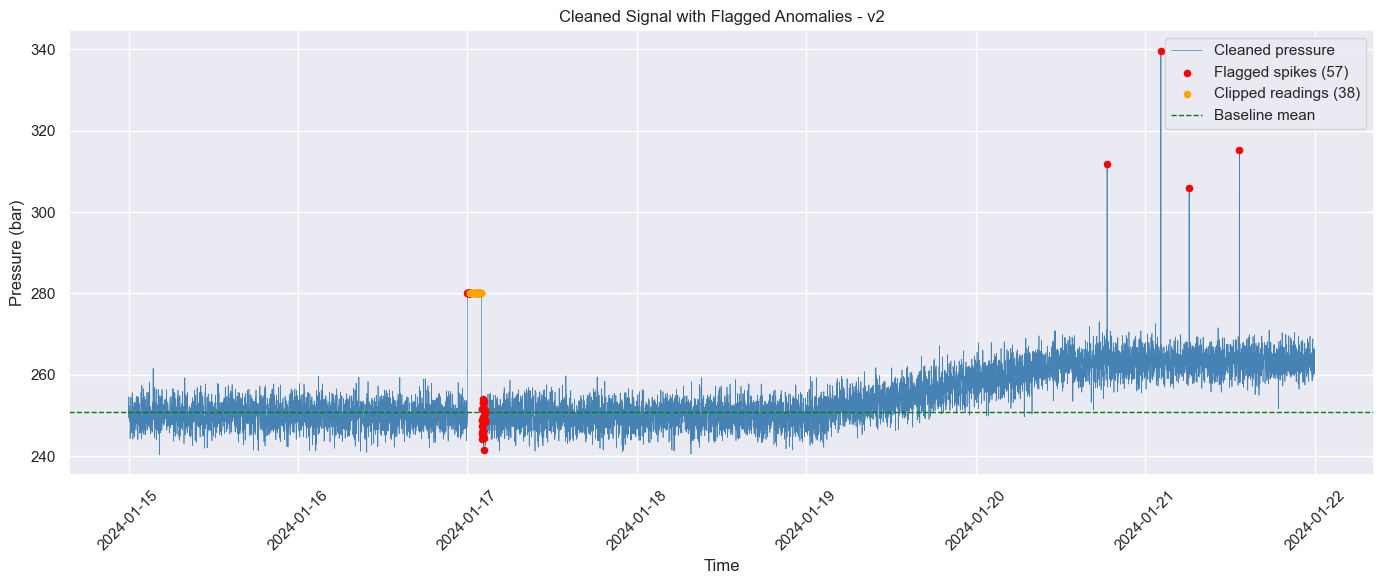

In [59]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(clean_df["timestamp"], clean_df["pressure"], 
        linewidth=0.5, color="steelblue", label="Cleaned pressure")

spikes_only = clean_df[clean_df["spike_flag"] == True]
ax.scatter(spikes_only["timestamp"], spikes_only["pressure"], 
           color="red", s=20, zorder=5, label=f"Flagged spikes ({len(spikes_only)})")

clipped_only = clean_df[clean_df["clipping_flag"] == True]
ax.scatter(clipped_only["timestamp"], clipped_only["pressure"],
           color="orange", s=20, zorder=5, label=f"Clipped readings ({len(clipped_only)})")

ax.axhline(y=baseline_mean, color="green", linestyle="--", linewidth=1, label="Baseline mean")
ax.set_title("Cleaned Signal with Flagged Anomalies - v2")
ax.set_ylabel("Pressure (bar)")
ax.set_xlabel("Time")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [60]:
# Create an expanded clipping exclusion zone
# Exclude clipped readings AND 60 minutes after clipping ends
clipping_exclusion = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)

spike_count = clean_df["spike_flag"].sum()
print(f"Spikes flagged: {spike_count}")

Spikes flagged: 24


In [61]:
# Create an expanded clipping exclusion zone
# Exclude clipped readings AND 60 minutes after clipping ends
clipping_exclusion = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)

spike_count = clean_df["spike_flag"].sum()
print(f"Spikes flagged: {spike_count}")

Spikes flagged: 24


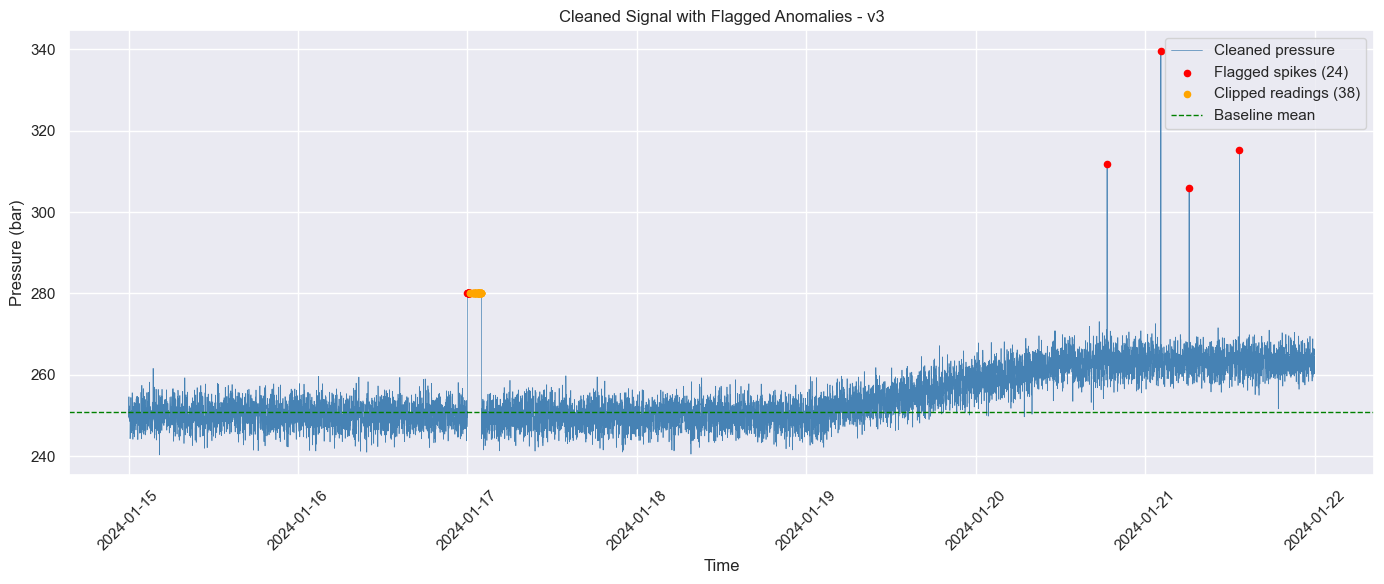

In [62]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(clean_df["timestamp"], clean_df["pressure"], 
        linewidth=0.5, color="steelblue", label="Cleaned pressure")

spikes_only = clean_df[clean_df["spike_flag"] == True]
ax.scatter(spikes_only["timestamp"], spikes_only["pressure"], 
           color="red", s=20, zorder=5, label=f"Flagged spikes ({len(spikes_only)})")

clipped_only = clean_df[clean_df["clipping_flag"] == True]
ax.scatter(clipped_only["timestamp"], clipped_only["pressure"],
           color="orange", s=20, zorder=5, label=f"Clipped readings ({len(clipped_only)})")

ax.axhline(y=baseline_mean, color="green", linestyle="--", linewidth=1, label="Baseline mean")
ax.set_title("Cleaned Signal with Flagged Anomalies - v3")
ax.set_ylabel("Pressure (bar)")
ax.set_xlabel("Time")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [63]:
# Exclude buffer zone before AND after clipping
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)

clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)

spike_count = clean_df["spike_flag"].sum()
print(f"Spikes flagged: {spike_count}")

Spikes flagged: 4


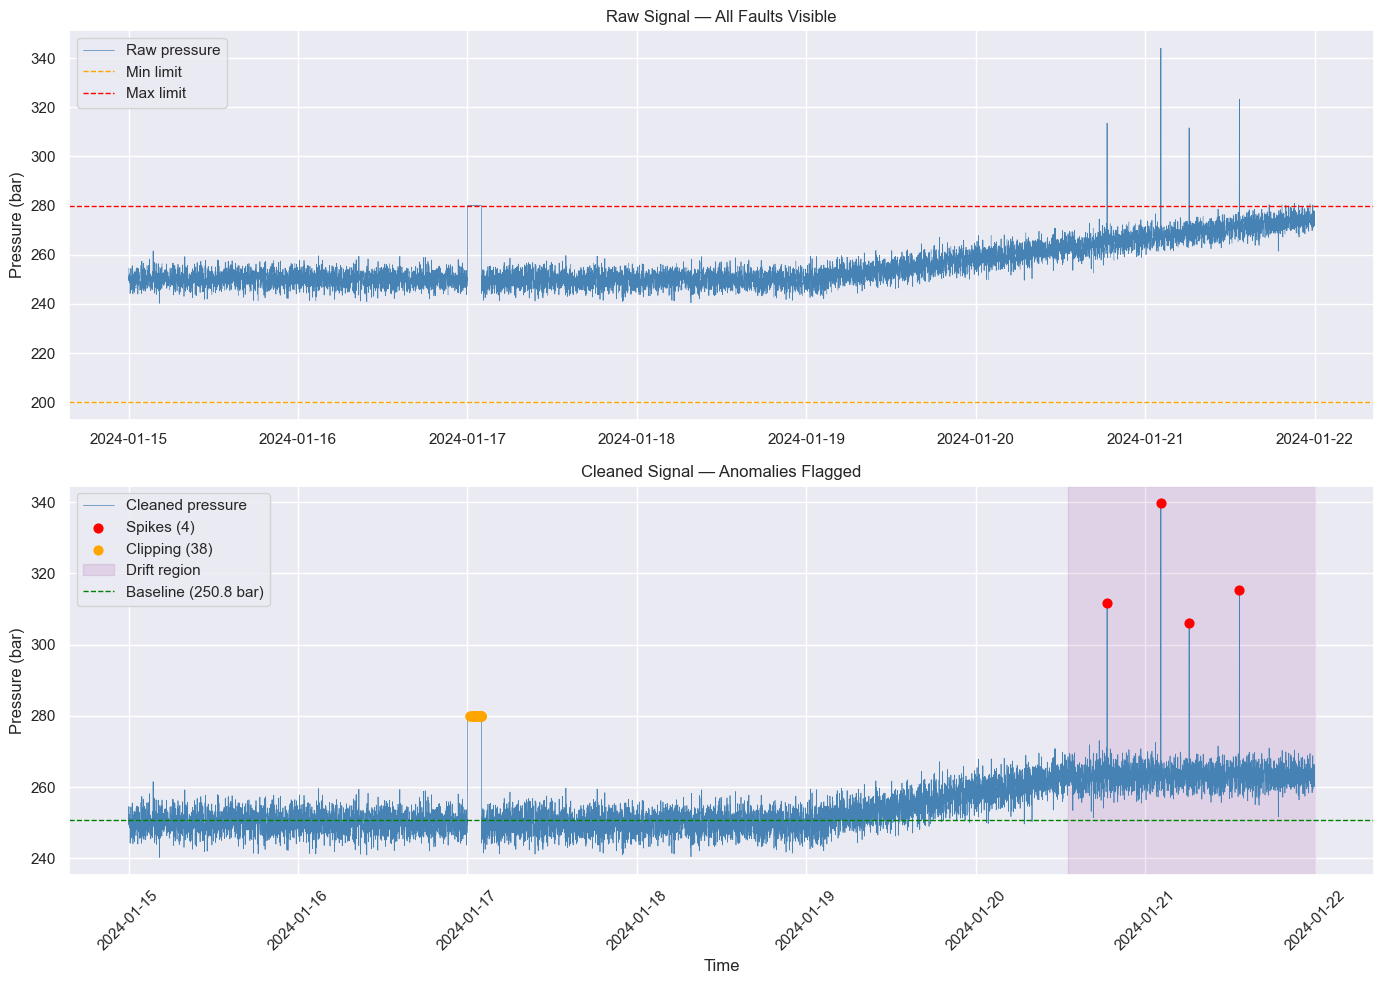

In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top - raw signal
ax1.plot(ts_df["timestamp"], ts_df["pressure"], 
         linewidth=0.5, color="steelblue", label="Raw pressure")
ax1.axhline(y=200, color="orange", linestyle="--", linewidth=1, label="Min limit")
ax1.axhline(y=280, color="red", linestyle="--", linewidth=1, label="Max limit")
ax1.set_title("Raw Signal — All Faults Visible")
ax1.set_ylabel("Pressure (bar)")
ax1.legend()

# Bottom - cleaned signal with flags
ax2.plot(clean_df["timestamp"], clean_df["pressure"], 
         linewidth=0.5, color="steelblue", label="Cleaned pressure")

spikes_only = clean_df[clean_df["spike_flag"] == True]
ax2.scatter(spikes_only["timestamp"], spikes_only["pressure"], 
            color="red", s=40, zorder=5, label=f"Spikes ({len(spikes_only)})")

clipped_only = clean_df[clean_df["clipping_flag"] == True]
ax2.scatter(clipped_only["timestamp"], clipped_only["pressure"],
            color="orange", s=40, zorder=5, label=f"Clipping ({len(clipped_only)})")

drift_only = clean_df[clean_df["drift_flag"] == True]
ax2.axvspan(drift_only["timestamp"].iloc[0], drift_only["timestamp"].iloc[-1],
            alpha=0.1, color="purple", label=f"Drift region")

ax2.axhline(y=baseline_mean, color="green", linestyle="--", 
            linewidth=1, label=f"Baseline ({baseline_mean:.1f} bar)")
ax2.set_title("Cleaned Signal — Anomalies Flagged")
ax2.set_ylabel("Pressure (bar)")
ax2.set_xlabel("Time")
plt.xticks(rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

In [65]:
print(f"Injected drift start: 2024-01-19 00:00 (day 4)")
print(f"Detected drift start: {drift_start_timestamp}")
print(f"Detection lag: {drift_start_timestamp - pd.Timestamp('2024-01-19 00:00')}")

Injected drift start: 2024-01-19 00:00 (day 4)
Detected drift start: 2024-01-20 13:00:00
Detection lag: 1 days 13:00:00


In [66]:
print(f"Baseline mean: {baseline_mean:.2f} bar")
print(f"Baseline std: {baseline_std:.2f} bar")
print(f"Current threshold (2 std): {baseline_mean + 2*baseline_std:.2f} bar")
print(f"Tighter threshold (1 std): {baseline_mean + 1*baseline_std:.2f} bar")
print(f"Tightest threshold (0.5 std): {baseline_mean + 0.5*baseline_std:.2f} bar")

# Also check what the hourly rolling mean looks like around day 4
drift_region = hourly_df[(hourly_df["timestamp"] >= "2024-01-18") & 
                          (hourly_df["timestamp"] <= "2024-01-21")]
print(f"\nHourly rolling mean around drift start:")
print(drift_region[["timestamp", "pressure", "rolling_mean"]].to_string())

Baseline mean: 250.85 bar
Baseline std: 4.98 bar
Current threshold (2 std): 260.81 bar
Tighter threshold (1 std): 255.83 bar
Tightest threshold (0.5 std): 253.34 bar

Hourly rolling mean around drift start:
              timestamp    pressure  rolling_mean
72  2024-01-18 00:00:00  249.894817    249.734933
73  2024-01-18 01:00:00  249.536878    249.631323
74  2024-01-18 02:00:00  250.128825    249.721286
75  2024-01-18 03:00:00  250.102090    249.810646
76  2024-01-18 04:00:00  250.160354    249.856746
77  2024-01-18 05:00:00  249.936147    249.832624
78  2024-01-18 06:00:00  250.243127    249.879421
79  2024-01-18 07:00:00  249.471569    249.865495
80  2024-01-18 08:00:00  249.950860    249.825008
81  2024-01-18 09:00:00  249.801460    249.859202
82  2024-01-18 10:00:00  250.150829    249.896029
83  2024-01-18 11:00:00  250.571068    249.995669
84  2024-01-18 12:00:00  249.835256    249.990705
85  2024-01-18 13:00:00  250.105100    250.038057
86  2024-01-18 14:00:00  249.614683    249.

In [67]:
print(f"Baseline std: {baseline_std:.2f} bar")
print(f"0.5 std = {0.5 * baseline_std:.2f} bar")
print(f"1.0 std = {1.0 * baseline_std:.2f} bar")
print(f"1.5 std = {1.5 * baseline_std:.2f} bar")

Baseline std: 4.98 bar
0.5 std = 2.49 bar
1.0 std = 4.98 bar
1.5 std = 7.47 bar


In [68]:
# Tighter drift threshold - 2 bar above or below baseline
drift_threshold_upper = baseline_mean + 2
drift_threshold_lower = baseline_mean - 2

# Find drift start - first hour where 12hr rolling mean exceeds either threshold
drift_hours = hourly_df[
    (hourly_df["rolling_mean"] > drift_threshold_upper) |
    (hourly_df["rolling_mean"] < drift_threshold_lower)
]

drift_start_timestamp = drift_hours["timestamp"].iloc[0]
print(f"Drift detected from: {drift_start_timestamp}")
print(f"Detection lag: {drift_start_timestamp - pd.Timestamp('2024-01-19 00:00')}")

Drift detected from: 2024-01-17 01:00:00
Detection lag: -2 days +01:00:00


In [69]:
# Check maximum rolling mean deviation during clean period
clean_period = hourly_df[hourly_df["timestamp"] < "2024-01-19"]
max_clean_deviation = np.abs(clean_period["rolling_mean"] - baseline_mean).max()
mean_clean_deviation = np.abs(clean_period["rolling_mean"] - baseline_mean).mean()

print(f"Max rolling mean deviation during clean period: {max_clean_deviation:.2f} bar")
print(f"Mean rolling mean deviation during clean period: {mean_clean_deviation:.2f} bar")
print()
print(f"Suggested threshold (max + 50% buffer): {max_clean_deviation * 1.5:.2f} bar")
print(f"Suggested threshold (max + 100% buffer): {max_clean_deviation * 2.0:.2f} bar")

Max rolling mean deviation during clean period: 4.24 bar
Mean rolling mean deviation during clean period: 1.24 bar

Suggested threshold (max + 50% buffer): 6.36 bar
Suggested threshold (max + 100% buffer): 8.48 bar


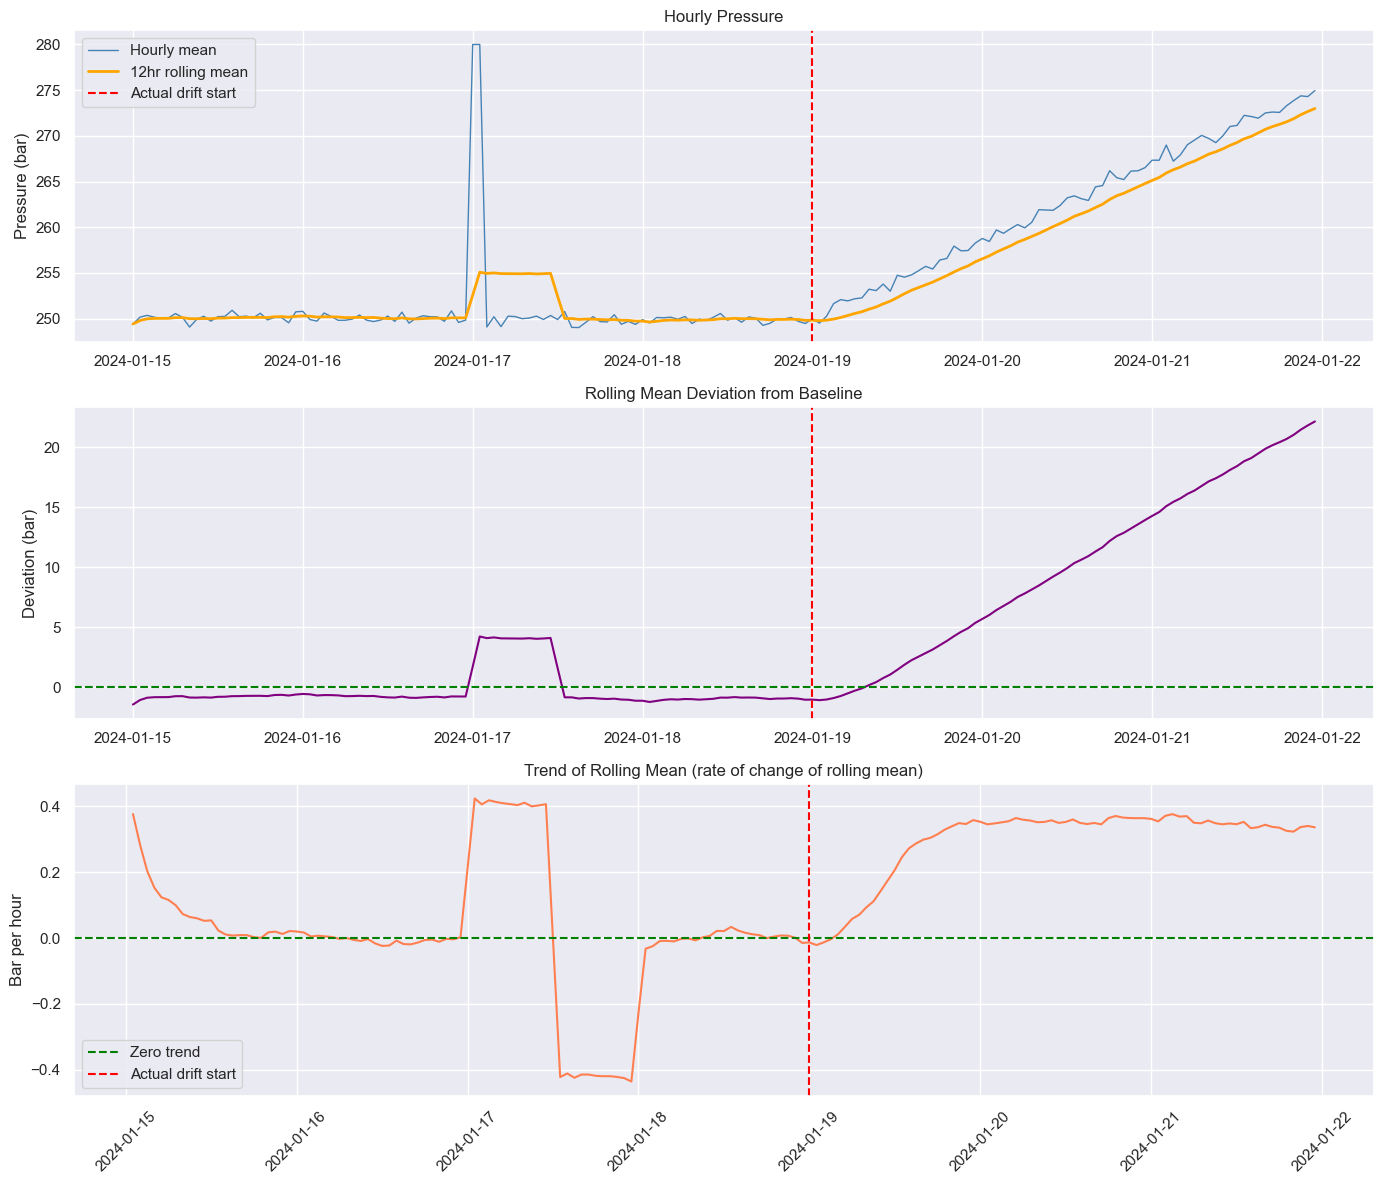

In [70]:
# Calculate how the rolling mean is changing over time
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()

# Rolling mean of that diff - is the change sustained?
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Plot both to visualise
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Top - hourly pressure
ax1.plot(hourly_df["timestamp"], hourly_df["pressure"],
         linewidth=1, color="steelblue", label="Hourly mean")
ax1.plot(hourly_df["timestamp"], hourly_df["rolling_mean"],
         linewidth=2, color="orange", label="12hr rolling mean")
ax1.axvline(x=pd.Timestamp("2024-01-19"), color="red", 
            linestyle="--", label="Actual drift start")
ax1.set_title("Hourly Pressure")
ax1.set_ylabel("Pressure (bar)")
ax1.legend()

# Middle - rolling mean deviation from baseline
ax2.plot(hourly_df["timestamp"], 
         hourly_df["rolling_mean"] - baseline_mean,
         linewidth=1.5, color="purple")
ax2.axhline(y=0, color="green", linestyle="--")
ax2.axvline(x=pd.Timestamp("2024-01-19"), color="red", linestyle="--")
ax2.set_title("Rolling Mean Deviation from Baseline")
ax2.set_ylabel("Deviation (bar)")

# Bottom - trend of rolling mean (your idea)
ax3.plot(hourly_df["timestamp"], hourly_df["rolling_mean_trend"],
         linewidth=1.5, color="coral")
ax3.axhline(y=0, color="green", linestyle="--", label="Zero trend")
ax3.axvline(x=pd.Timestamp("2024-01-19"), color="red", 
            linestyle="--", label="Actual drift start")
ax3.set_title("Trend of Rolling Mean (rate of change of rolling mean)")
ax3.set_ylabel("Bar per hour")
ax3.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

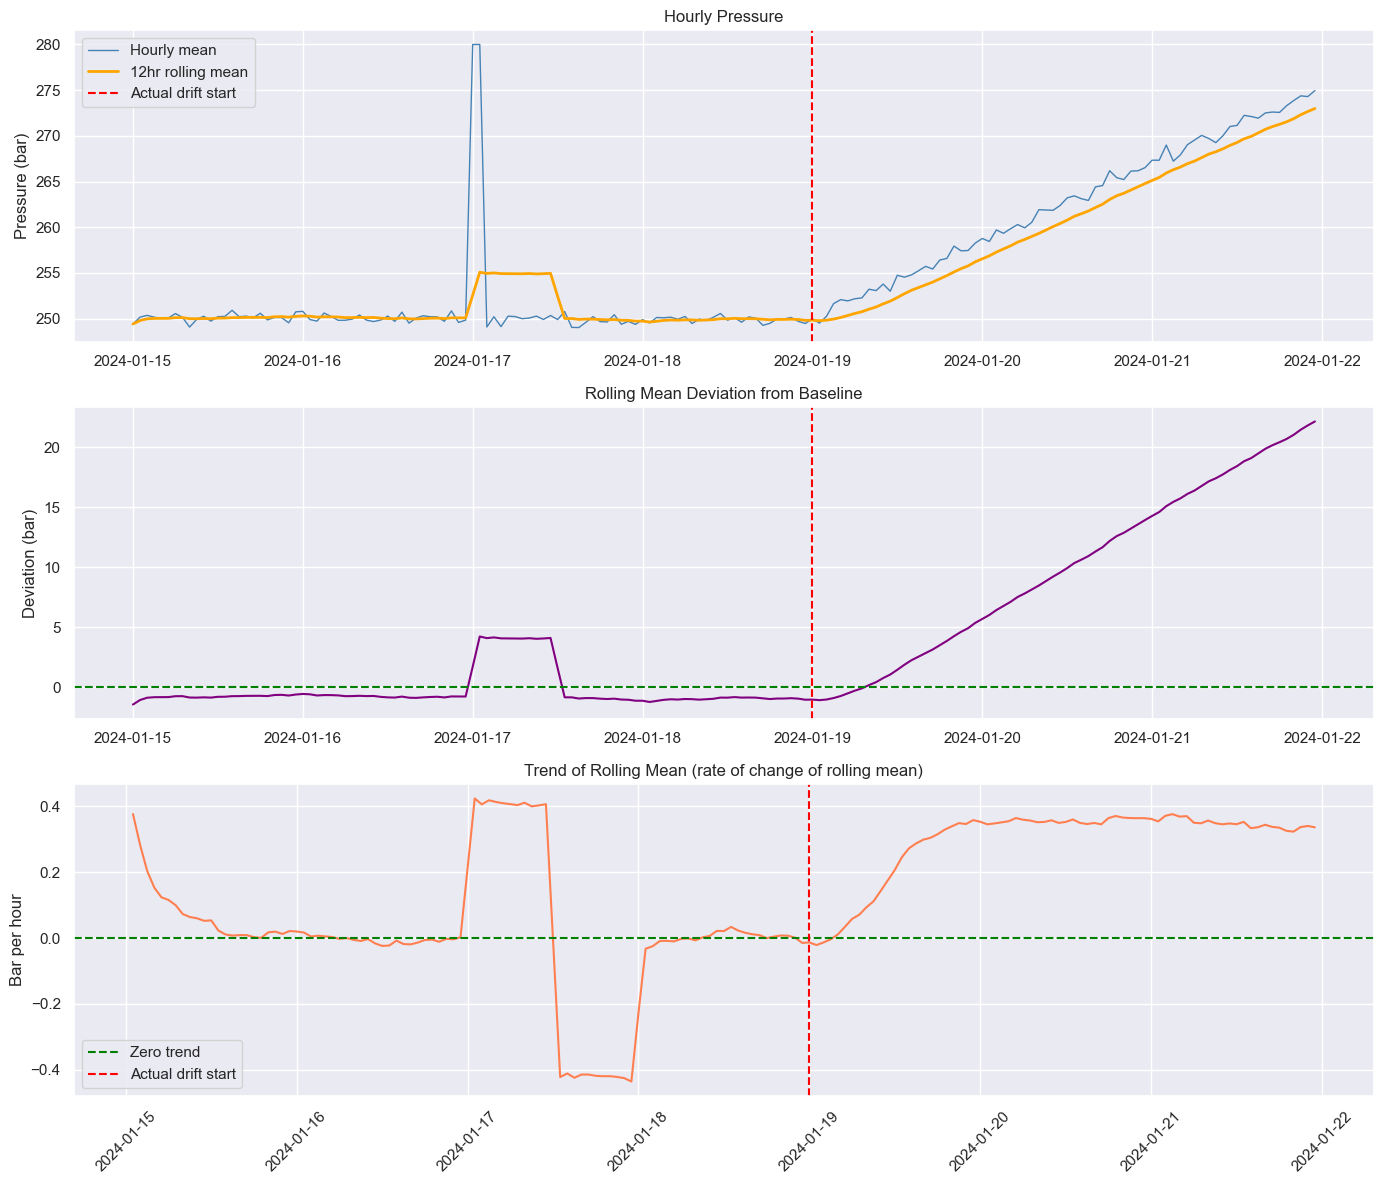

In [71]:
# Calculate how the rolling mean is changing over time
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()

# Rolling mean of that diff - is the change sustained?
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Plot both to visualise
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Top - hourly pressure
ax1.plot(hourly_df["timestamp"], hourly_df["pressure"],
         linewidth=1, color="steelblue", label="Hourly mean")
ax1.plot(hourly_df["timestamp"], hourly_df["rolling_mean"],
         linewidth=2, color="orange", label="12hr rolling mean")
ax1.axvline(x=pd.Timestamp("2024-01-19"), color="red", 
            linestyle="--", label="Actual drift start")
ax1.set_title("Hourly Pressure")
ax1.set_ylabel("Pressure (bar)")
ax1.legend()

# Middle - rolling mean deviation from baseline
ax2.plot(hourly_df["timestamp"], 
         hourly_df["rolling_mean"] - baseline_mean,
         linewidth=1.5, color="purple")
ax2.axhline(y=0, color="green", linestyle="--")
ax2.axvline(x=pd.Timestamp("2024-01-19"), color="red", linestyle="--")
ax2.set_title("Rolling Mean Deviation from Baseline")
ax2.set_ylabel("Deviation (bar)")

# Bottom - trend of rolling mean (your idea)
ax3.plot(hourly_df["timestamp"], hourly_df["rolling_mean_trend"],
         linewidth=1.5, color="coral")
ax3.axhline(y=0, color="green", linestyle="--", label="Zero trend")
ax3.axvline(x=pd.Timestamp("2024-01-19"), color="red", 
            linestyle="--", label="Actual drift start")
ax3.set_title("Trend of Rolling Mean (rate of change of rolling mean)")
ax3.set_ylabel("Bar per hour")
ax3.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# ══════════════════════════════════════════════════════
# COMPLETE DATA CLEANING PIPELINE - Final Version
# ══════════════════════════════════════════════════════

# Always work on a fresh copy of raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: FILL MISSING VALUES ────────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
missing_after = clean_df["pressure"].isna().sum()
print(f"Step 2 - Missing values filled: {missing_before} → {missing_after} remaining")

# ── STEP 3: DETECT SPIKES ──────────────────────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()

# Clipping exclusion zone - buffer before and after clipping
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)
clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 3 - Spikes flagged: {spike_count}")

# ── STEP 4: DETECT AND CORRECT DRIFT ──────────────────
# Resample to hourly means
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Baseline from first 3 days
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

# Rate of change of rolling mean - your idea!
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Find drift start - where trend becomes consistently positive
trend_threshold = baseline_std * 0.1
drift_hours = hourly_df[hourly_df["rolling_mean_trend"] > trend_threshold]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
drift_lag = drift_start_timestamp - pd.Timestamp("2024-01-19 00:00")
print(f"Step 4 - Drift detected from: {drift_start_timestamp}")
print(f"Step 4 - Detection lag: {drift_lag}")

# Map to minute level and apply correction
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 4 - Drift readings flagged: {drift_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")

Step 1 - Clipped readings flagged: 38
Step 2 - Missing values filled: 538 → 0 remaining
Step 3 - Spikes flagged: 4


IndexError: single positional indexer is out-of-bounds

In [73]:
print(f"Baseline std: {baseline_std:.2f} bar")
print(f"Trend threshold: {baseline_std * 0.1:.4f} bar/hour")
print(f"\nHourly trend values around drift start:")
check_period = hourly_df[(hourly_df["timestamp"] >= "2024-01-18") & 
                          (hourly_df["timestamp"] <= "2024-01-21")]
print(check_period[["timestamp", "rolling_mean", "rolling_mean_trend"]].to_string())

Baseline std: 4.98 bar
Trend threshold: 0.4982 bar/hour

Hourly trend values around drift start:
              timestamp  rolling_mean  rolling_mean_trend
72  2024-01-18 00:00:00    249.732212           -0.225047
73  2024-01-18 01:00:00    249.631144           -0.030554
74  2024-01-18 02:00:00    249.709670           -0.025004
75  2024-01-18 03:00:00    249.797333           -0.010265
76  2024-01-18 04:00:00    249.848215           -0.009642
77  2024-01-18 05:00:00    249.815905           -0.011872
78  2024-01-18 06:00:00    249.852327           -0.004200
79  2024-01-18 07:00:00    249.845799           -0.002828
80  2024-01-18 08:00:00    249.803876           -0.008921
81  2024-01-18 09:00:00    249.829908           -0.001859
82  2024-01-18 10:00:00    249.875552            0.003180
83  2024-01-18 11:00:00    249.979230            0.019061
84  2024-01-18 12:00:00    249.988969            0.021396
85  2024-01-18 13:00:00    250.043607            0.034372
86  2024-01-18 14:00:00    249.99

In [74]:
# ══════════════════════════════════════════════════════
# COMPLETE DATA CLEANING PIPELINE - Final Version
# ══════════════════════════════════════════════════════

# Always work on a fresh copy of raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# ── STEP 2: FILL MISSING VALUES ────────────────────────
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
missing_after = clean_df["pressure"].isna().sum()
print(f"Step 2 - Missing values filled: {missing_before} → {missing_after} remaining")

# ── STEP 3: DETECT SPIKES ──────────────────────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()

# Clipping exclusion zone - buffer before and after clipping
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)
clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 3 - Spikes flagged: {spike_count}")

# ── STEP 4: DETECT AND CORRECT DRIFT ──────────────────
# Resample to hourly means
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Baseline from first 3 days
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

# Rate of change of rolling mean - your idea!
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Find drift start - where trend becomes consistently positive
trend_threshold = 0.1
drift_hours = hourly_df[
    (hourly_df["rolling_mean_trend"] > trend_threshold) &
    (hourly_df.index >= 24)
]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
drift_lag = drift_start_timestamp - pd.Timestamp("2024-01-19 00:00")
print(f"Step 4 - Drift detected from: {drift_start_timestamp}")
print(f"Step 4 - Detection lag: {drift_lag}")

# Map to minute level and apply correction
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 4 - Drift readings flagged: {drift_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")

Step 1 - Clipped readings flagged: 38
Step 2 - Missing values filled: 538 → 0 remaining
Step 3 - Spikes flagged: 4
Step 4 - Drift detected from: 2024-01-17 00:00:00
Step 4 - Detection lag: -2 days +00:00:00
Step 4 - Drift readings flagged: 7200

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Missing values filled: 538 (5.3%)
Spikes flagged:        4 (0.0%)
Drift periods:         7200 (71.4%)


In [75]:
print(f"Clipping event timestamp: day 2 = 2024-01-17")
print(f"Drift falsely detected: {drift_start_timestamp}")
print()

# Check trend values around the clipping event
check_clipping = hourly_df[
    (hourly_df["timestamp"] >= "2024-01-16") & 
    (hourly_df["timestamp"] <= "2024-01-18")
]
print(check_clipping[["timestamp", "rolling_mean", "rolling_mean_trend"]].to_string())

Clipping event timestamp: day 2 = 2024-01-17
Drift falsely detected: 2024-01-17 00:00:00

             timestamp  rolling_mean  rolling_mean_trend
24 2024-01-16 00:00:00    250.254406            0.015298
25 2024-01-16 01:00:00    250.235883            0.013543
26 2024-01-16 02:00:00    250.139934            0.002402
27 2024-01-16 03:00:00    250.173360            0.005560
28 2024-01-16 04:00:00    250.169103            0.004519
29 2024-01-16 05:00:00    250.148076            0.003105
30 2024-01-16 06:00:00    250.091041            0.000563
31 2024-01-16 07:00:00    250.098358            0.003233
32 2024-01-16 08:00:00    250.115676           -0.003023
33 2024-01-16 09:00:00    250.089791           -0.007168
34 2024-01-16 10:00:00    250.104576           -0.001407
35 2024-01-16 11:00:00    250.026311           -0.015915
36 2024-01-16 12:00:00    249.994767           -0.021637
37 2024-01-16 13:00:00    249.978730           -0.021429
38 2024-01-16 14:00:00    250.074346           -0.00546

In [76]:
# ══════════════════════════════════════════════════════
# COMPLETE DATA CLEANING PIPELINE - Final Version
# ══════════════════════════════════════════════════════

# Always work on a fresh copy of raw data
clean_df = ts_df.copy()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 - Clipped readings flagged: {clipping_count}")

# STEP 2 REVISED - handle clipping and missing values separately

# First interpolate across clipped regions
clean_df["pressure"] = clean_df["pressure"].interpolate(method="linear")

# Then forward/backward fill any remaining missing values
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
print(f"Step 2 - Missing values filled: {missing_before} → {clean_df['pressure'].isna().sum()} remaining")

# ── STEP 3: DETECT SPIKES ──────────────────────────────
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()

# Clipping exclusion zone - buffer before and after clipping
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)
clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 3 - Spikes flagged: {spike_count}")

# ── STEP 4: DETECT AND CORRECT DRIFT ──────────────────
# Resample to hourly means
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Baseline from first 3 days
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

# Rate of change of rolling mean - your idea!
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Find drift start - where trend becomes consistently positive
trend_threshold = 0.1
drift_hours = hourly_df[
    (hourly_df["rolling_mean_trend"] > trend_threshold) &
    (hourly_df.index >= 24)
]
drift_start_timestamp = drift_hours["timestamp"].iloc[0]
drift_lag = drift_start_timestamp - pd.Timestamp("2024-01-19 00:00")
print(f"Step 4 - Drift detected from: {drift_start_timestamp}")
print(f"Step 4 - Detection lag: {drift_lag}")

# Map to minute level and apply correction
drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]
hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
drift_rate = (hourly_drift["pressure"].iloc[-1] - hourly_drift["pressure"].iloc[0]) / len(hourly_drift)
drift_length = n - drift_start_idx
correction = np.zeros(n)
correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
clean_df["pressure"] = clean_df["pressure"] - correction
clean_df["drift_flag"] = False
clean_df.loc[drift_start_idx:, "drift_flag"] = True
drift_count = clean_df["drift_flag"].sum()
print(f"Step 4 - Drift readings flagged: {drift_count}")

# ── SUMMARY ───────────────────────────────────────────
print(f"\n── Data Quality Summary ──────────────────")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")

Step 1 - Clipped readings flagged: 38
Step 2 - Missing values filled: 0 → 0 remaining
Step 3 - Spikes flagged: 4
Step 4 - Drift detected from: 2024-01-17 00:00:00
Step 4 - Detection lag: -2 days +00:00:00
Step 4 - Drift readings flagged: 7200

── Data Quality Summary ──────────────────
Total readings:        10,080
Clipped readings:      38 (0.4%)
Missing values filled: 0 (0.0%)
Spikes flagged:        4 (0.0%)
Drift periods:         7200 (71.4%)


In [77]:
# Check what happens to clipped values step by step
print("Raw pressure at clipping region (rows 2880-2890):")
print(ts_df["pressure"][2880:2890].values)
print()
print("After clipping flag and NaN replacement:")
print(clean_df["pressure"][2880:2890].values)
print()
print(f"Clipping flags in that region:")
print(clean_df["clipping_flag"][2880:2890].values)

Raw pressure at clipping region (rows 2880-2890):
[280. 280. 280. 280. 280. 280. 280. 280. 280.  nan]

After clipping flag and NaN replacement:
[280.         280.00069623 280.00139246 280.00208869 280.00278492
 280.00348116 280.00417739 280.00487362 280.00556985 280.00626608]

Clipping flags in that region:
[False False False False False False False False False False]


In [78]:
# Reset to completely fresh raw data
clean_df = ts_df.copy()
print(f"Fresh copy created - max pressure: {clean_df['pressure'].max():.1f}")
print(f"Values at exactly 280: {(clean_df['pressure'] == 280.0).sum()}")

Fresh copy created - max pressure: 344.1
Values at exactly 280: 112


In [79]:
print("After Step 1 - clipping region check (rows 2880-2890):")
print(f"Pressure values: {clean_df['pressure'][2880:2890].values}")
print(f"Clipping flags: {clean_df['clipping_flag'][2880:2890].values}")
print(f"Total clipping flags: {clean_df['clipping_flag'].sum()}")
print(f"Total NaN after Step 1: {clean_df['pressure'].isna().sum()}")

After Step 1 - clipping region check (rows 2880-2890):
Pressure values: [280. 280. 280. 280. 280. 280. 280. 280. 280.  nan]


KeyError: 'clipping_flag'